<b>Setup</b>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

<b>Import der Daten</b>


In [2]:
df = pd.read_csv("../data/ai_student_impact_dataset.csv")

df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


<b>Der Datensatz im Überblick:</b>

Zu sehen sind die jeweiligen Spalten des Datensatzes sowie die Anzahl der Einträge und dem jeweilig verwendeten Datentyp.


In [3]:
df.info()
df.describe()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           50000 non-null

(50000, 16)

**Ergänzend zum Überblick die Beschreibung der Spalten von Kaggle**

<table>
  <thead>
    <tr>
      <th>Spaltenname</th>
      <th>Datentyp</th>
      <th>Beschreibung</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Student_ID</td>
      <td>Integer</td>
      <td>Unique numeric identifier for each student: 100001–150000</td>
    </tr>
    <tr>
      <td>Major_Category</td>
      <td>Categorical</td>
      <td>Student's field of study: STEM, Business, Humanities, Medical, Arts</td>
    </tr>
    <tr>
      <td>Year_of_Study</td>
      <td>Categorical</td>
      <td>Academic standing: Freshman, Sophomore, Junior, Senior, Graduate</td>
    </tr>
    <tr>
      <td>Pre_Semester_GPA</td>
      <td>Float</td>
      <td>GPA at the start of the semester: ranges from ~1.18 to 4.00</td>
    </tr>
    <tr>
      <td>Post_Semester_GPA</td>
      <td>Float</td>
      <td>GPA at the end of the semester: ranges from ~1.00 to 4.00</td>
    </tr>
    <tr>
      <td>Weekly_GenAI_Hours</td>
      <td>Float</td>
      <td>Average hours per week spent using Generative AI tools: 0-40 hrs</td>
    </tr>
    <tr>
      <td>Primary_Use_Case</td>
      <td>Categorical</td>
      <td>Main purpose for which the student uses AI: Copywriting/Drafting, Summarizing reading, Debugging/Troubleshooting, Ideation, Direct answer generation</td>
    </tr>
    <tr>
      <td>Prompt_Engineering_Skill</td>
      <td>Categorical</td>
      <td>Self-assessed proficiency in crafting effective prompts: Beginner, Intermediate, Advanced</td>
    </tr>
    <tr>
      <td>Tool_Diversity</td>
      <td>Integer</td>
      <td>Number of distinct AI tools used: 1-5</td>
    </tr>
    <tr>
      <td>Paid_Subscription</td>
      <td>Boolean</td>
      <td>Whether the student has a paid AI subscription: either True or False</td>
    </tr>
    <tr>
      <td>Traditional_Study_Hours</td>
      <td>Float</td>
      <td>Weekly hours devoted to traditional non-AI study methods: 1-36 hrs</td>
    </tr>
    <tr>
      <td>Perceived_AI_Dependency</td>
      <td>Integer</td>
      <td>Student's self-rated dependency on AI tools: score from 1 (low) to 10 (high)</td>
    </tr>
    <tr>
      <td>Institutional_Policy</td>
      <td>Categorical</td>
      <td>The institution's official stance on AI usage: Allowed with citation, Strictly ban, Actively encouraged</td>
    </tr>
    <tr>
      <td>Anxiety_Level_During_Exams</td>
      <td>Integer</td>
      <td>Self-reported exam anxiety: score from 1 (low) to 10 (high)</td>
    </tr>
    <tr>
      <td>Skill_Retention_Score</td>
      <td>Float</td>
      <td>Score measuring how well students retained learned skills post-semester: 0–100 </td>
    </tr>
    <tr>
      <td>Burnout_Risk_Level</td>
      <td>Categorical</td>
      <td>Assessed burnout risk: Low, Medium, High</td>
    </tr>
  </tbody>
</table>


<b>Leere Einträge im Datensatz finden und entfernen:</b>

Entfernt zunächst alle leeren Zellen, final wird eine Liste ausgegeben die die jeweilige Anzahl an entfernten Zellen in der Spalte enthält.


In [4]:
df.isnull().sum()
df_clean = df.dropna()

df_clean.isnull().sum()

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

<b>Kategorische Spalten finden:</b>

Diese lassen sich an ihrem Datentyp(object) erkennen, anhand dessen sie auch gefiltert werden können


In [5]:
categorical_columns = df_clean.select_dtypes(include=["object"]).columns

print("Kategorische Spalten:", categorical_columns)

Kategorische Spalten: Index(['Major_Category', 'Year_of_Study', 'Primary_Use_Case',
       'Prompt_Engineering_Skill', 'Institutional_Policy',
       'Burnout_Risk_Level'],
      dtype='str')


/var/folders/c2/5nr_z4f541sc959bs2nm7wjw0000gn/T/ipykernel_45336/1053059782.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df_clean.select_dtypes(include=["object"]).columns


<b>One-Hot Encoding durchführen:</b>

Führt zunächst das One-Hot Encoding durch und visualisiert danach die entstandene Tabelle mit den neuen Spalten.<br>
drop_first = erste Möglickeit für Dummy Entries wird gedroppt/als Standard gesetzt, d.h gibt es k-1 neue Spalten wenn k für die Möglichkeiten steht, die eine Kategorische Variable annehmen kann.
<br>
<br>
Beispiel:<br>
Aus der Kategorische Variable Burnout_Risk_Level mit Drei möglichen Werten zwei Spalten abgeleitet:<br>
Burnout_Risk_Level_Low & Burnout_Risk_Level_Medium.<br>
Sind beide Spalten für einen Studenten auf False gesetzt, greift automatisch der Standardfall. Für das Burnout_Risk_Level ist der Standardfall Burnout_Risk_Level_High. Die beim Encoding entstandene transformierten Daten können in der folgenden Tabelle eingesehen werden.


In [6]:
df_encoded = pd.get_dummies(df_clean, columns=categorical_columns, drop_first=True)

df_encoded.head()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,...,Primary_Use_Case_Debugging/Troubleshooting,Primary_Use_Case_Direct_Answer_Generation,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Prompt_Engineering_Skill_Beginner,Prompt_Engineering_Skill_Intermediate,Institutional_Policy_Allowed_With_Citation,Institutional_Policy_Strict_Ban,Burnout_Risk_Level_Low,Burnout_Risk_Level_Medium
0,100001,2.418,23.31,1,True,8.13,5,6,2.393,86.44,...,False,False,False,False,True,False,True,False,False,False
1,100002,3.821,1.12,5,False,16.65,3,9,3.696,69.39,...,False,False,True,False,False,False,True,False,True,False
2,100003,3.398,21.26,2,False,10.35,5,9,3.499,73.93,...,False,False,False,True,True,False,False,True,False,True
3,100004,3.789,1.82,4,False,15.23,2,2,4.000,63.58,...,False,False,False,False,False,True,True,False,False,True
4,100005,3.635,9.29,4,False,12.55,4,4,3.798,100.00,...,True,False,False,False,False,False,True,False,False,True


<b>Pairplot erstellen:</b>

bei der Erstellung werden nur die urspünglich nummerischen Spalten verwendet, da durch das One-Hot-Encoding viele Spalten entstehen die das pairplot unübersichtlicher machen. Konkret werden die Spalten angezeigt, welche ursprünglich int und float Werte enthalten.


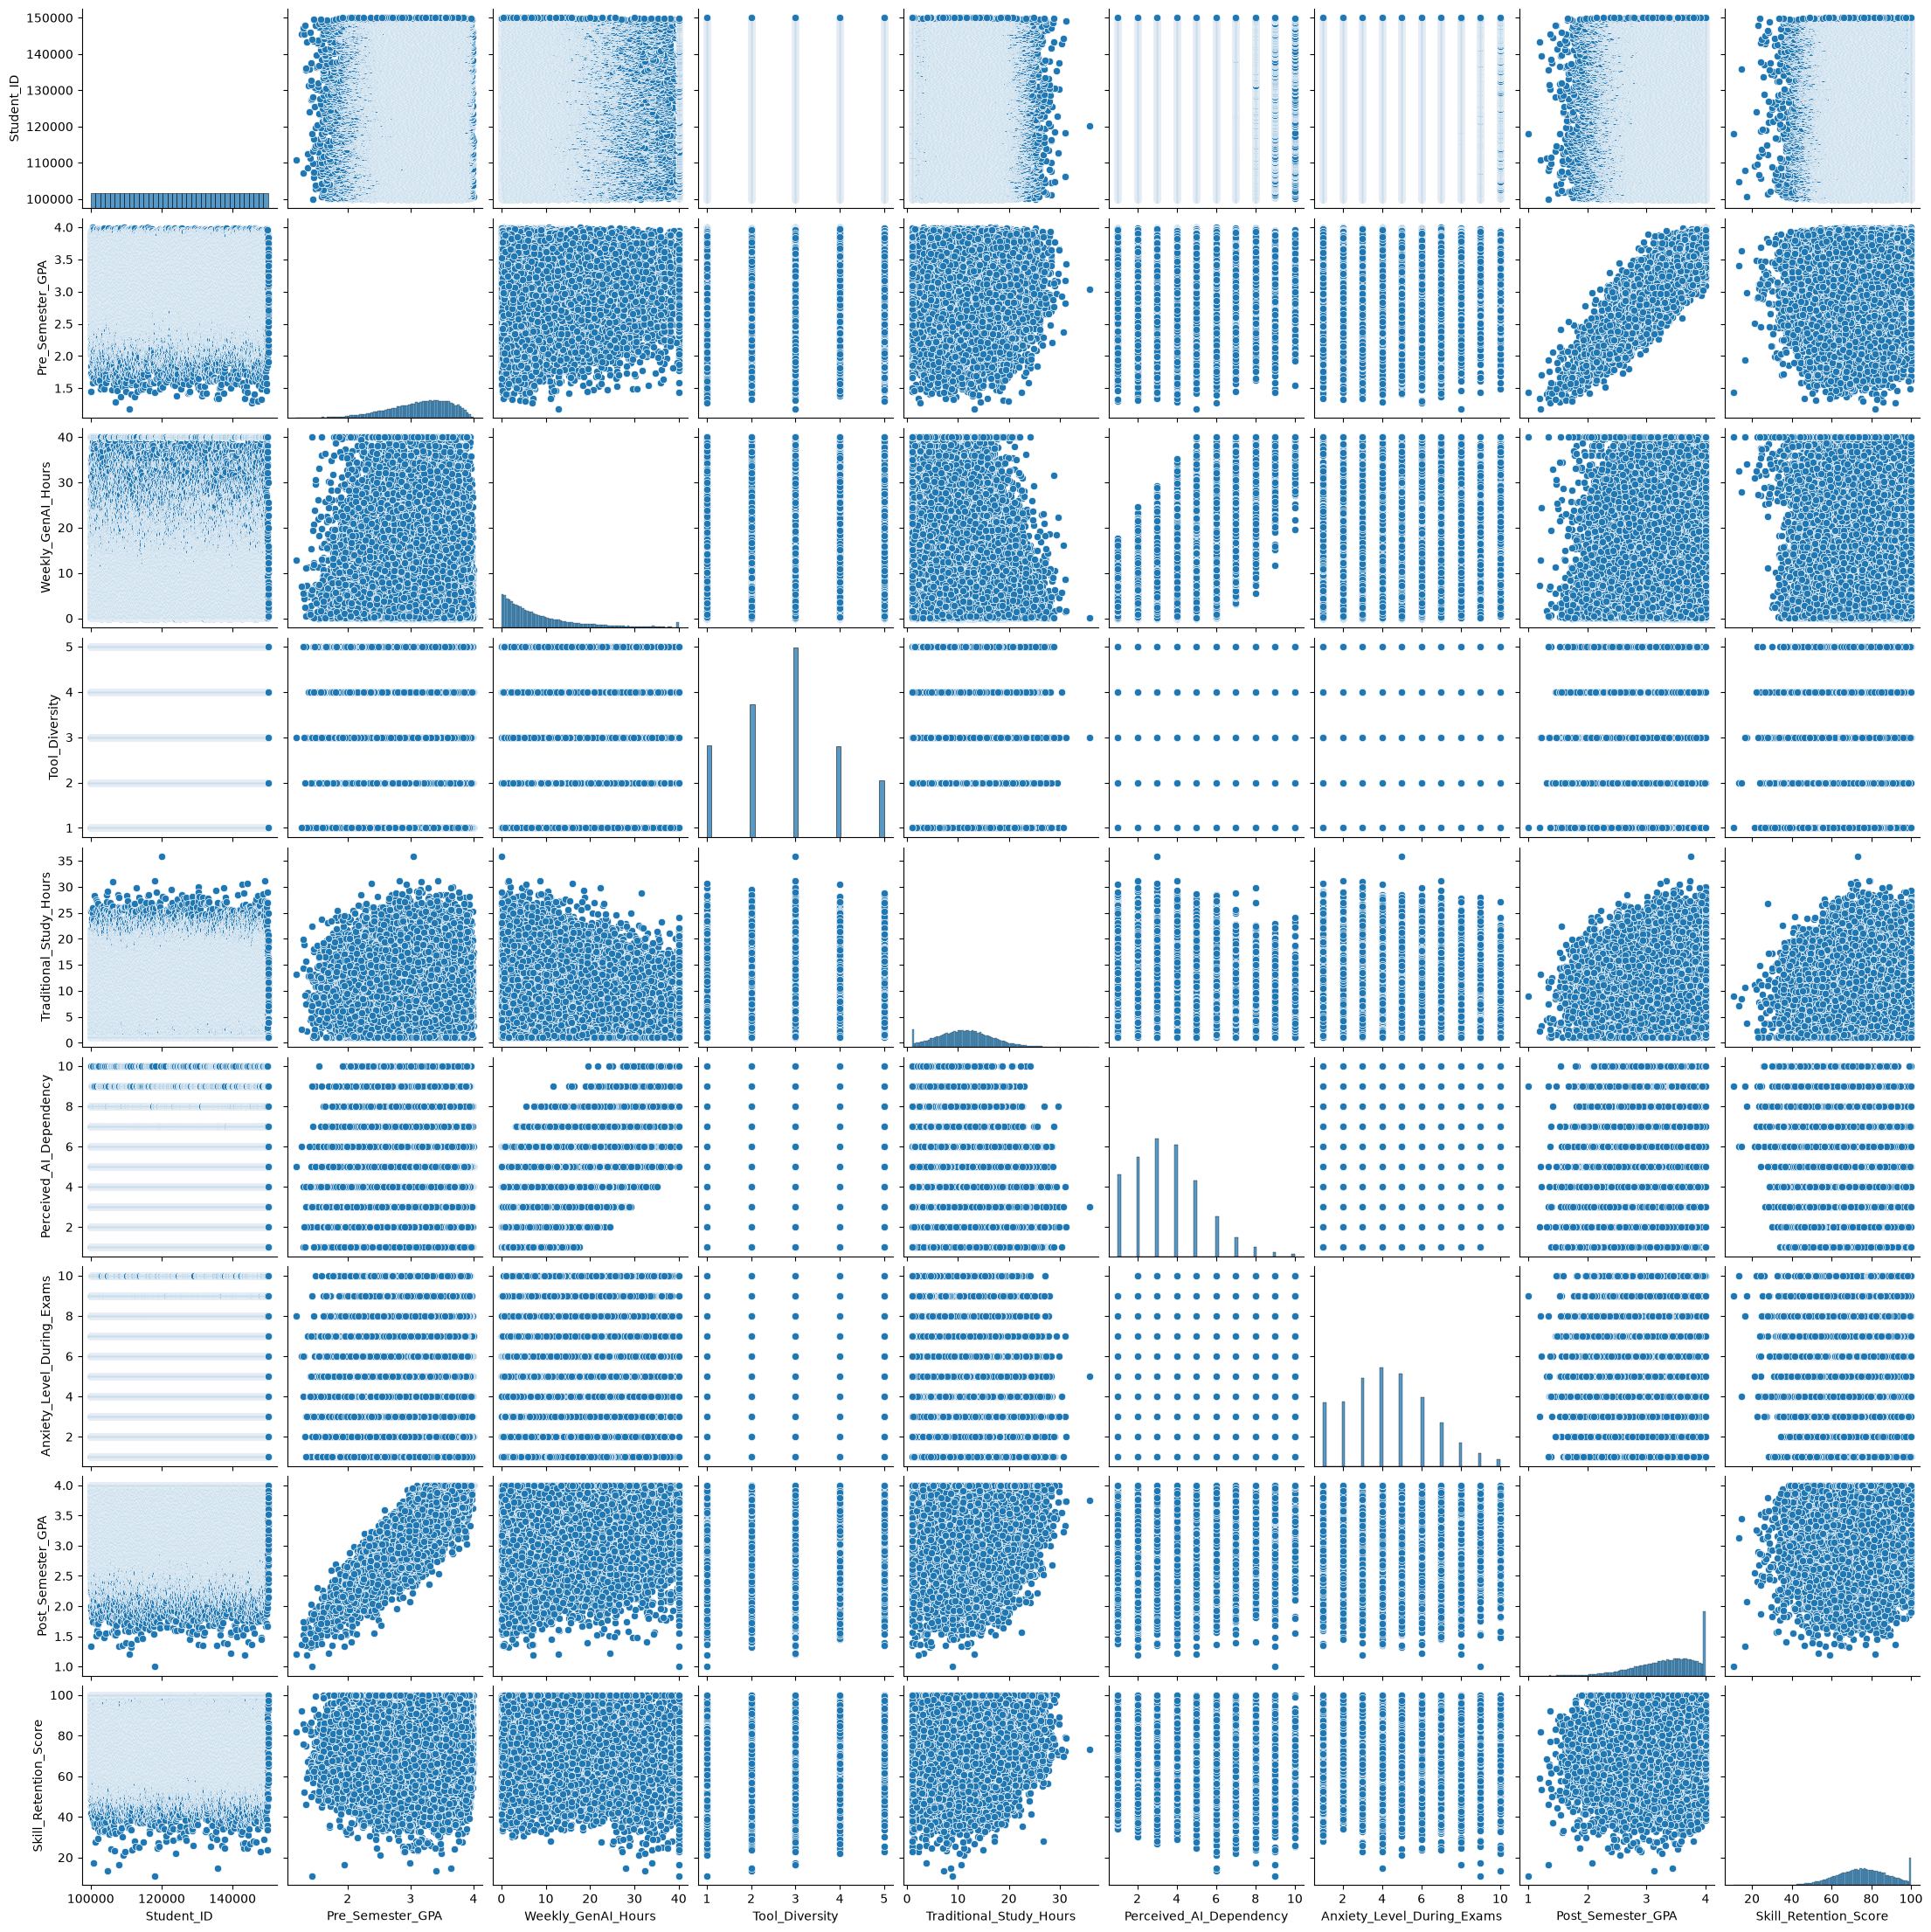

In [7]:
numeric_columns = df_clean.select_dtypes(include=["int64", "float64"]).columns

sns.pairplot(df_clean[numeric_columns])
plt.show()

<b>Interpretation Pairplot:</b>
<br>
<table>
  <thead>
    <tr>
      <th>Variable</th>
      <th>Einfluss auf Post_Semester_GPA (Abschlussnote)</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Pre_Semester_GPA</td>
      <td>Stark positiv</td>
    </tr>
    <tr>
      <td>Skill_Retention_Score</td>
      <td>Stark positiv (oder die Folge guter Noten)</td>
    </tr>
    <tr>
      <td>Traditional_Study_Hours</td>
      <td>Schwach positiv</td>
    </tr>
    <tr>
      <td>Weekly_GenAI_Hours</td>
      <td>Kein klarer linearer Effekt</td>
    </tr>
    <tr>
      <td>Anxiety / AI_Dependency</td>
      <td>Kein klarer Effekt sichtbar</td>
    </tr>
  </tbody>
</table>


Der Pairplot dient als erste explorative Analyse der numerischen Variablen. Dabei zeigt sich vor allem ein deutlicher positiver Zusammenhang zwischen dem Pre_Semester_GPA und dem Post_Semester_GPA. Studierende mit einem höheren GPA vor dem Semester erreichen tendenziell auch nach dem Semester einen höheren GPA. Auch der Skill_Retention_Score zeigt einen positiven Zusammenhang mit dem Post_Semester_GPA. Da hier jedoch nur eine grafische Betrachtung vorliegt, kann daraus keine Kausalität abgeleitet werden.

Für die Variablen Weekly_GenAI_Hours, Traditional_Study_Hours, Perceived_AI_Dependency und Anxiety_Level_During_Exams sind im Pairplot keine ähnlich starken linearen Zusammenhänge sichtbar. Die Interpretation des vollständigen Pairplots ist durch die vielen Variablen und die Größe der Grafik jedoch schwierig. Deshalb wird im nächsten Schritt ein reduzierter Pairplot mit ausgewählten Variablen erstellt.

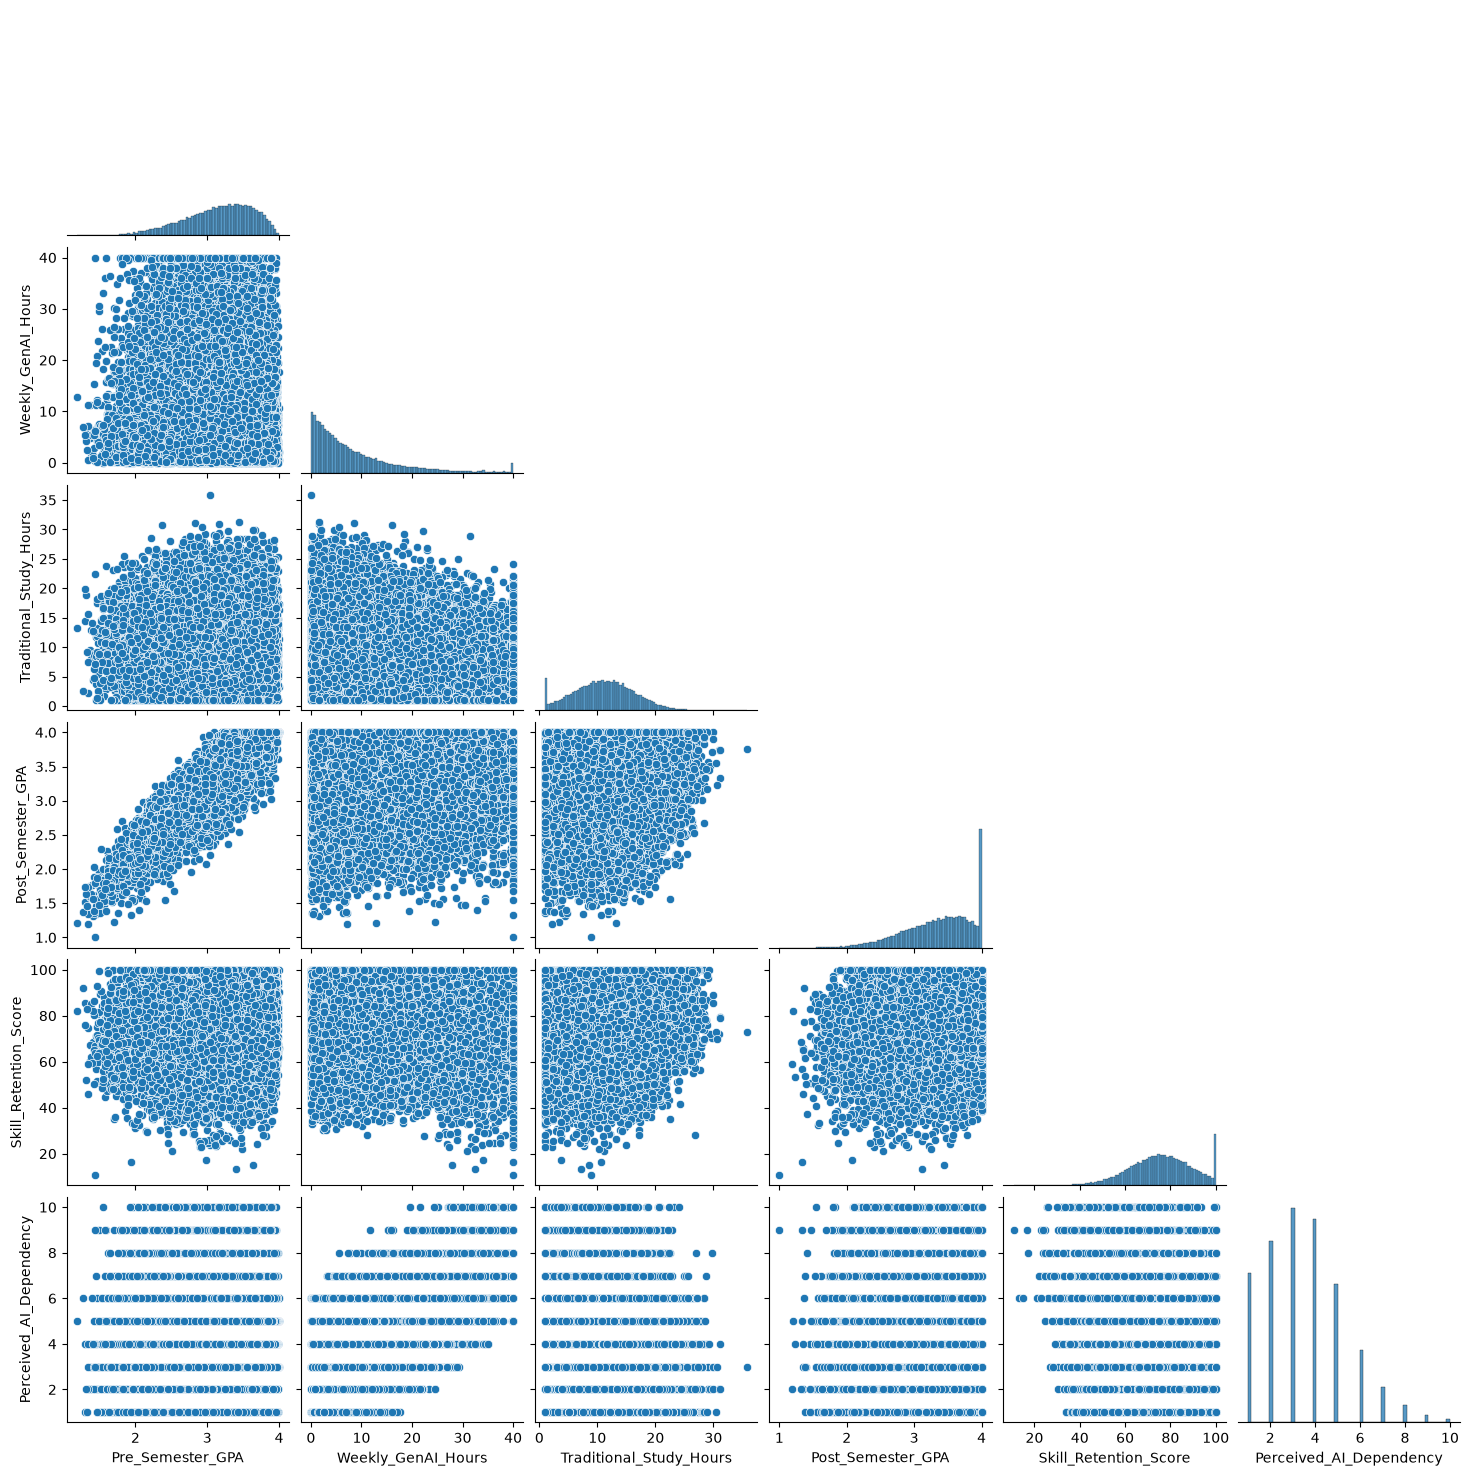

In [8]:
pairplot_cols = [
    "Pre_Semester_GPA",
    "Weekly_GenAI_Hours",
    "Traditional_Study_Hours",
    "Post_Semester_GPA",
    "Skill_Retention_Score",
    "Perceived_AI_Dependency"
]

sns.pairplot(
    df[pairplot_cols],
    corner=True,
    diag_kind="hist"
)

plt.show()

Der reduzierte Pairplot bestätigt den Eindruck aus der ersten Visualisierung. Der stärkste sichtbare Zusammenhang besteht zwischen Pre_Semester_GPA und Post_Semester_GPA. Dieser Zusammenhang ist plausibel, da frühere akademische Leistungen häufig ein guter Prädiktor für spätere akademische Leistungen sind.

Bei Weekly_GenAI_Hours ist dagegen kein klarer linearer Zusammenhang mit dem Post_Semester_GPA erkennbar. Eine höhere wöchentliche Nutzung generativer KI geht in dieser grafischen Betrachtung also nicht eindeutig mit einem höheren oder niedrigeren GPA einher. Auch Traditional_Study_Hours zeigt nur einen schwächeren Zusammenhang. Diese Beobachtungen werden später mithilfe des Regressionsbaums und der Feature Importance genauer überprüft.

<b>Regression oder Klassifikation:</b>
<br>
Kurzbeschreibung Regression: Regression ist eine Methode des Supervised Learning die verwendet wird, um numerische Werte vorherzusagen. Das Modell versucht konkrete Zahlen wie Preise, Temperaturen oder Umsätze möglichst genau vorherzusagen.
<br>
<br>
Kurzbeschreibung Klassifikation: Klassifikation ist eine Methode des Supervised Learning. Ziel ist es, Daten anhand ihrer Merkmale in definierte Kategorien einzuteilen. Das Modell versucht beispielsweise zu entscheiden, ob eine e-mail Spam ist oder nicht.
<br>
<br>
_Output Variable_:
Post_Semester_GPA (Die Note nach dem Semester, Wertebereich = 1.0–4.0, kontinuierliche numerische Variable)
<br>
<br>
_Input Variablen_:
<table>
  <thead>
    <tr>
      <th>Variable</th>
      <th>Skalenniveau</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Pre_Semester_GPA</td>
      <td>Kontinuierlich</td>
    </tr>
    <tr>
      <td>Weekly_GenAI_Hours</td>
      <td>Kontinuierlich</td>
    </tr>
    <tr>
      <td>Tool_Diversity</td>
      <td>Diskret (1–5)</td>
    </tr>
    <tr>
      <td>Traditional_Study_Hours</td>
      <td>Kontinuierlich</td>
    </tr>
    <tr>
      <td>Perceived_AI_Dependency</td>
      <td>Ordinal (1–10)</td>
    </tr>
    <tr>
      <td>Anxiety_Level_During_Exams</td>
      <td>Ordinal (1–10)</td>
    </tr>
    <tr>
      <td>Skill_Retention_Score</td>
      <td>Kontinuierlich</td>
    </tr>
    <tr>
      <td>One-Hot-Encoded Variablen</td>
      <td>Binär (0/1)</td>
    </tr>
  </tbody>
</table>


<b>Warum Regression:</b>

1. Der Post_Semester_GPA ist eine kontinuierliche Variable mit vielen möglichen Werten (1.0, 1.1, 1.2, ... 4.0). Regression bildet genau die Methodik ab, die hier für eine Vorhersage benötigt wird.
2. Drohender Informationsverlust bei Klassifikation: Würde man den GPA in Klassen einteilen, ginge die Abstufung verloren. Ein Unterschied zwischen 2.9 und 3.1 wäre dann irrelevant, obwohl er existiert.

Für eine Klassifikation könnte eine angepasste Fragestellung beispielsweise lauten:<br>
"Besteht ein Student das Semester (Klassifikation in Ja oder Nein) anhand der Input-Variablen".


<b>Fragestellung für Prediction und Inference</b>
<br>
<br>
Inference Frage: Welchen _Einfluss_ haben die einzelnen Input-Variablen auf den Post_Semester_GPA?

Prediction Frage: Wie _präzise_ lässt sich anhand der Input-Variablen der Post_Semester_GPA eines Studierenden vorhersagen?

<b>Einordnung in den Forschungsstand:</b>
<br>
Die Fragestellung knüpft an aktuelle Diskussionen zur Nutzung generativer KI im Studium an. In der Studie von Smerdon (2024) wurde beispielsweise untersucht, ob die Nutzung von KI-Tools bei einer essaybasierten Prüfungsleistung mit besseren Ergebnissen verbunden ist. Die Studie zeigt, dass KI-Nutzende zwar teilweise andere Ausgangsbedingungen aufweisen können, nach Kontrolle weiterer Faktoren jedoch kein statistisch signifikanter Leistungsunterschied festgestellt wurde.
<br>
<br>
Unser Projekt untersucht eine ähnliche Frage auf Basis des vorliegenden Datensatzes: Es soll geprüft werden, ob KI-bezogene Variablen wie Weekly_GenAI_Hours, Primary_Use_Case oder Prompt_Engineering_Skill im Modell eine relevante Rolle für die Vorhersage des Post_Semester_GPA spielen. Dabei ist wichtig, dass unser Modell keine Kausalität beweist. Es zeigt lediglich, welche Variablen für die Vorhersage in diesem Datensatz besonders wichtig sind.

<b>Training und Evaluation des Regression-Tree-Models:</b>
<br>
<br>
1: Aufteilung des Datensatzes in Trainings und Testdaten (80/20 Split).<br>
2: Suche nach optimalen Parametern (im Fokus : max_depth, min_sample_leaf, min_sample_split, ccp_alpha).<br>
3: Erstellung eines Baumes mit optimalen Parametern.<br>
4: Overfitting Check.<br>
5: Visualisierung des Overfitting.<br>
6: Erzeugung einer Vorhersage.<br>
7: Evaluation des Baumes nach R2-Score und Feature Importance.<br>
8: Visualisierung des Baumes.<br>

<b>Aufteilung in Training & Testdaten(1) + Suche nach Parametern(2)</b>

Die Variable Student_ID wird vor dem Training entfernt, da sie nur eine eindeutige Kennnummer für jede Person darstellt. Sie enthält keine inhaltliche Information über Lernverhalten, KI-Nutzung oder Studienleistung. Wenn eine solche ID im Modell bleibt, kann sie zu zufälligen und nicht interpretierbaren Aufteilungen führen. Für die Vorhersage neuer Studierender wäre sie außerdem nicht sinnvoll nutzbar. Deshalb wird sie aus den Input-Variablen ausgeschlossen.

In [9]:
# Drop der STUDENT_ID aufgrund ihrer Irrelevanz
df_encoded = df_encoded.drop(columns=["Student_ID"])

# Festlegung der Zielvariablen
target = "Post_Semester_GPA"

# Festlegung des RandomState
random_state_unique = 42

# Drop des targets aus der df_encoded
X = df_encoded.drop(columns=[target])

# Definition des Targets als y
y = df_encoded[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state= random_state_unique
)

param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_leaf': [10, 50, 100, 200],
    'ccp_alpha': [0.0, 0.001, 0.01, 0.1],
    'min_samples_split': [20, 100, 200, 400]
}
grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,                
    scoring='r2',
    return_train_score=True
)
grid_search.fit(X_train, y_train)
print("Beste Parameter:", grid_search.best_params_)
print("Bester CV R²:", grid_search.best_score_)

Beste Parameter: {'ccp_alpha': 0.0, 'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 100}
Bester CV R²: 0.8818402772521304


<b>Erstellung des Trees mit optimalen Parametern(3)</b>

In [10]:
tree = DecisionTreeRegressor(
    max_depth = grid_search.best_params_['max_depth'],
    random_state = random_state_unique,
    min_samples_leaf = grid_search.best_params_['min_samples_leaf'],
    min_samples_split = grid_search.best_params_['min_samples_split'],
    ccp_alpha = grid_search.best_params_['ccp_alpha']
)

tree.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",100
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes

<b>Overfitting-Check(4)</b>
<br>
<br>
Um Overfitting festzustellen werden die Ergebnisse der Test und Trainingsdaten Prediction mit dem R2 Score gegeneinander verglichen.


In [11]:
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

print("Overfitting-Check")
print(f"R² Training: {r2_score(y_train, y_train_pred):.4f}")
print(f"R² Test:     {r2_score(y_test, y_test_pred):.4f}")
print(f"Differenz:   {r2_score(y_train, y_train_pred) - r2_score(y_test, y_test_pred):.4f}")
print()
print(f"RMSE Training: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.4f}")
print(f"RMSE Test:     {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}")


Overfitting-Check
R² Training: 0.9004
R² Test:     0.8841
Differenz:   0.0163

RMSE Training: 0.1568
RMSE Test:     0.1673


**Interpretation des Overfitting Check anhand des R²-Score**

Das optimierte Modell zeigt eine sehr gute Vorhersagequalität mit einem R²-Score von 0.884 auf den Testdaten. Der durchschnittliche RMSE liegt bei 0.167 Punkten, was auf der GPA Skala von 1.0 bis 4.0 als präzise bewertet werden kann. Der Overfitting-Check bestätigt die Robustheit des Modells: Die Differenz zwischen Training-R² (0.900) und Test-R² (0.884) beträgt 1,6%, was unter dem allgemeinen Schwellenwert von 5% liegt. Das Modell kann somit gut auf neuen Daten vorhersagen treffen und es liegt kein Overfitting vor.<br>
<br>
Overfitting konnte vor allem durch die Anpassung des Parameter max_depth reduziert werden. Durch den Grid-Search konnten hier die optimalen Einstellungen ermittelt werden. Insgesamt konnte so die Modellqualität von einem R²-Score von 79% im Training, auf 90% gesteigert werden.

<b>Overfitting Visualisierung(5)</b>

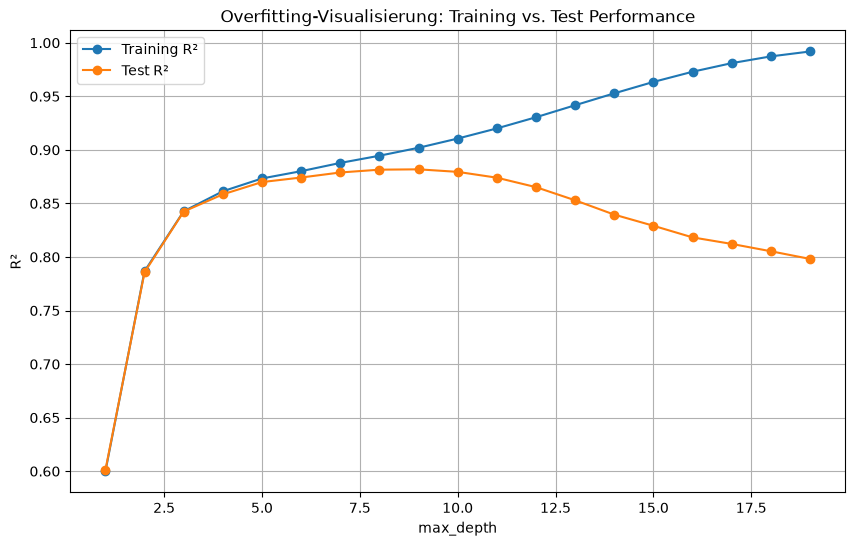

In [12]:
train_scores = []
test_scores = []
depths = range(1, 20)
for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(r2_score(y_train, model.predict(X_train)))
    test_scores.append(r2_score(y_test, model.predict(X_test)))
plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, label='Training R²', marker='o')
plt.plot(depths, test_scores, label='Test R²', marker='o')
plt.xlabel('max_depth')
plt.ylabel('R²')
plt.title('Overfitting-Visualisierung: Training vs. Test Performance')
plt.legend()
plt.grid(True)
plt.show()

**Beschreibung des Schaubilds**<br>
Das Diagramm zeigt den Zusammenhang zwischen max_depth und R²-Score des Modells im Training und Test und validiert weiter die Ergebnisse des Grid-Search. Zu sehen ist, dass ab einer Tiefe von 10 die Qualität des Modells im Test stark nachlässt, woraus sich schließen lässt, dass ab diesem Punkt Overfitting vorliegt.

<b>Erzeugung einer Vorhersage(6)</b>

In [13]:
y_pred = tree.predict(X_test)

print("Prediction :", y_pred)

Prediction : [2.35435106 3.10868493 3.0641     ... 3.41408163 3.01549123 3.21140887]


**Evaluation des Baums nach R2 Score und Feature Importance(7)**

In [14]:
r2 = r2_score(y_test, y_pred)

print("R²:", r2)


importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
).head(15)

R²: 0.8840802225476223


,Feature,Importance
0,Pre_Semester_GPA,0.957787
4,Traditional_Study_Hours,0.023674
1,Weekly_GenAI_Hours,0.004966
7,Skill_Retention_Score,0.003728
17,Primary_Use_Case_Direct_Answer_Generation,0.002396
16,Primary_Use_Case_Debugging/Troubleshooting,0.001994
14,Year_of_Study_Senior,0.001344
12,Year_of_Study_Graduate,0.001069
21,Prompt_Engineering_Skill_Intermediate,0.001006
20,Prompt_Engineering_Skill_Beginner,0.000519


**Evaluation der Ergebnisse**
<br>
<br>
_Beantwortung der Inference Frage_:<br>
Der Regressionsbaum zeigt, dass der Pre_Semester_GPA mit einer Feature Importance von 95,8% die mit Abstand wichtigste Variable für die Vorhersage des Post_Semester_GPA ist. Die Entscheidungen des Baumes basieren fast ausschließlich auf dieser Variable. Das deutet darauf hin, dass die Leistungen vor Semesterbeginn der stärkste Faktor für die Leistung innerhalb des nächsten Semester sind.<br>
<br>
Die zweitwichtigste Variable ist die Traditional_Study_Hours mit einer Importance von 2,4%. Der Beitrag zur Vorhersage ist deutlich geringer als der des Pre_Semester_GPA, aber größer als der aller KI-bezogenen Variablen.<br>
<br>
Die Variable Weekly_GenAI_Hours erreicht lediglich eine Feature Importance von 0,5%. Auch weitere KI-bezogene Merkmale wie Tool Diversity, Perceived AI Dependency oder Prompt Engineering Skills weisen nur sehr geringe Werte auf. Daraus lässt sich schließen, dass die Variablen in diesem Datensatz nur einen geringen Teil zur Vorhersage des Post_Semester_GPA beitragen.<br>
<br>
Insgesamt deutet das Modell darauf hin, dass bisherige Leistungen und in einem geringem Maße traditionelles Lernen stärker mit dem Post_Semester_GPA zusammenhängen als Umfang und Art von KI-Tool-Nutzung. Die Ergebnisse liefern damit keine Hinweise darauf, dass die Nutzung von KI-Tools einen starken oder vergleichbaren Einfluss für den Semestererfolg hat wie die bisherigen Leistungen eines Studenten. 
<br>
<br>
_Beantwortung der Prediction Frage_:<br>
Der hohe R²-Wert von 88,4% zeigt, dass sich der Post_Semester_GPA mit den verfügbaren Input-Variablen präzise vorhersagen lässt. Insbesondere der Pre_Semester_GPA liefert dabei einen Großteil der Vorhersage. Das Modell kann die akademische Leistung eines Studenten nach dem Semester also mit hoher Genauigkeit schätzen.<br>
<br>
Gleichzeitig zeigt die Analyse der Feature Importance für die Inference Frage, dass diese hohe Genauigkeit fast vollständig auf dem Pre_Semester_GPA basiert. Die zusätzlichen Variablen, insbesondere die verschiedenen Maße der KI-Tool-Nutzung, verbessern die Vorhersage nur gering. Die hohe Qualität des Modells beruht damit hauptsächlich auf der Stabilität akademischer Leistungen eines Studenten über den Zeitraum seines Studiums.
<br>
<br>
Vergleich zu den Ergebnissen der Referenzstudie



**Baum Visualisierung (Mehr als fünf Ebenen erzeugen hohe Wartezeiten (Parameter max_depth))(8)**

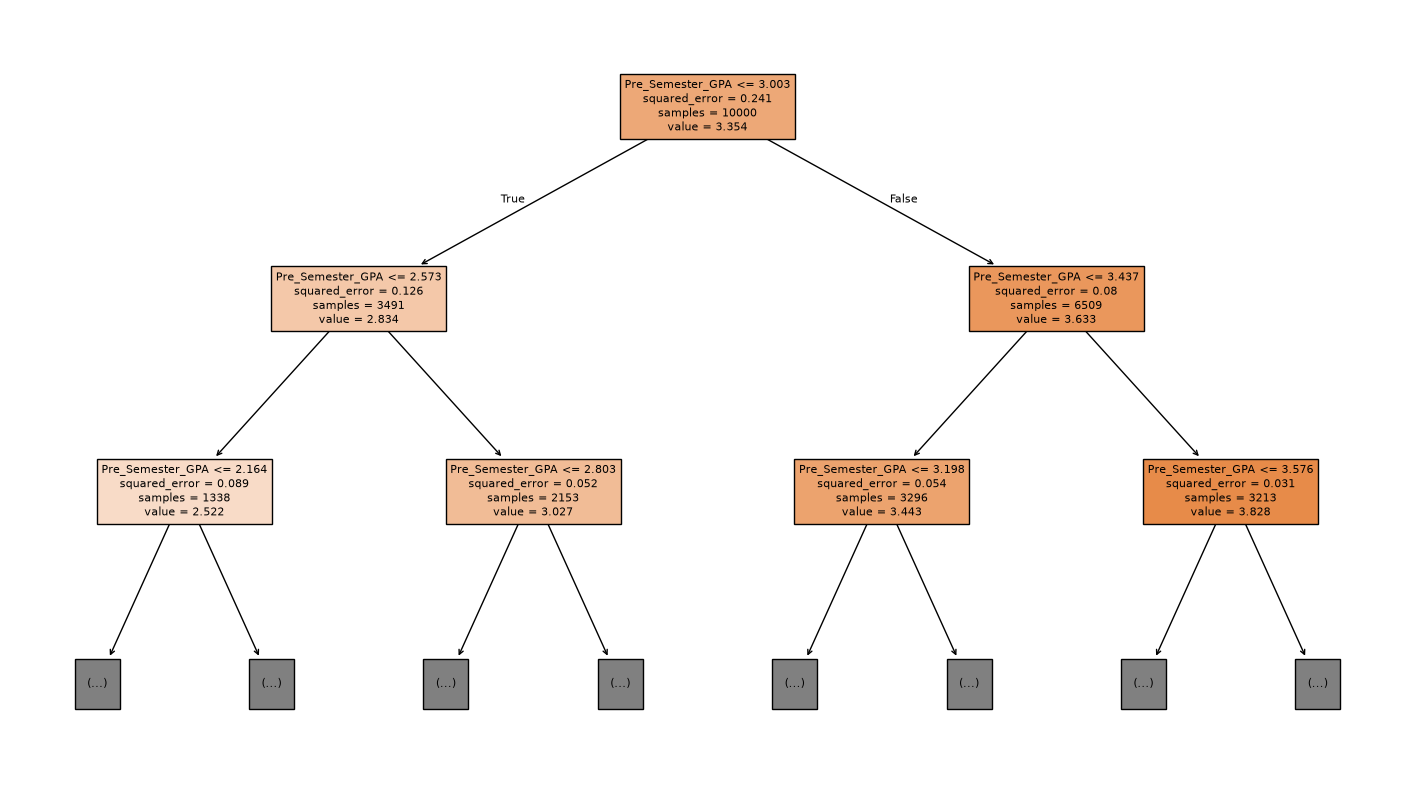

In [15]:
tree.fit(X_test,y_test)

plt.figure(figsize=(18,10))

plot_tree(
    tree,
    max_depth=2,
    filled=True,
    feature_names=X.columns
)

plt.show()